In [19]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Import project functions
from src.data_loading import load_data
from src.data_cleaning import clean_data
from src.analysis import *
from src.visualization import *

In [ ]:
data_path = "../data/processed/Philadelphia_Crime_Incidents_2018_2022.csv"

df = load_data(data_path)

df.head()

d:\major project\src\data_loading.py:8: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,gdb_geomattr_data,lat,lng
0,0101000020E610000010569AFCC5C652C0D822E56BF2FF...,108.0,0101000020110F00003D99A6CDC9E45FC19B870084D68F...,108,24,2,2021-08-14 04:00:00+00,2021-08-14,00:00:00,3.0,2.021241e+11,1800 BLOCK E TIOGA ST,100,Homicide - Criminal,-75.105834,39.999586,NaN,39.999586,-75.105834
1,0101000020E6100000604A47E07FC152C0A0D7796AE103...,124.0,0101000020110F00009F652981D4DB5FC1834F9A323394...,124,8,1,2021-01-15 05:00:00+00,2021-01-15,00:00:00,15.0,2.021080e+11,7900 BLOCK STATE RD CFCF,100,Homicide - Criminal,-75.023430,40.030317,NaN,40.030317,-75.023430
2,0101000020E610000090FB2CB54FC152C0F8391E031704...,621.0,0101000020110F0000E6F48AAF82DB5FC1B36D62A56E94...,620,8,1,2021-04-19 04:00:00+00,2021-04-19,00:00:00,8.0,2.021080e+11,8100 BLOCK STATE RD CFCF,100,Homicide - Criminal,-75.020490,40.031952,NaN,40.031952,-75.020490
3,0101000020E610000090FB2CB54FC152C0F8391E031704...,731.0,0101000020110F0000E6F48AAF82DB5FC1B36D62A56E94...,730,8,1,2021-04-26 04:00:00+00,2021-04-26,00:00:00,20.0,2.021080e+11,8100 BLOCK STATE RD,100,Homicide - Criminal,-75.020490,40.031952,NaN,40.031952,-75.020490
4,0101000020E6100000B08ED65D28CA52C0B83362BF5705...,9325.0,0101000020110F00007191C76F89EA5FC1BC6F936ED295...,9315,14,1,2021-10-20 04:00:00+00,2021-10-20,00:00:00,11.0,2.021140e+11,5300 BLOCK CHEW AV,100,Homicide - Criminal,-75.158714,40.041740,NaN,40.041740,-75.158714


In [21]:
# Basic information about the dataset

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (736033, 19)

Column names:
['the_geom', 'cartodb_id', 'the_geom_webmercator', 'objectid', 'dc_dist', 'psa', 'dispatch_date_time', 'dispatch_date', 'dispatch_time', 'hour', 'dc_key', 'location_block', 'ucr_general', 'text_general_code', 'point_x', 'point_y', 'gdb_geomattr_data', 'lat', 'lng']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736033 entries, 0 to 736032
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   the_geom              419040 non-null  object 
 1   cartodb_id            420001 non-null  float64
 2   the_geom_webmercator  419040 non-null  object 
 3   objectid              736033 non-null  int64  
 4   dc_dist               736033 non-null  int64  
 5   psa                   735663 non-null  object 
 6   dispatch_date_time    736033 non-null  object 
 7   dispatch_date         736033 non-null  object 
 8   dispatch_time         736033 non-

In [22]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Rows and Columns: (736033, 19)

Column Names:
['the_geom', 'cartodb_id', 'the_geom_webmercator', 'objectid', 'dc_dist', 'psa', 'dispatch_date_time', 'dispatch_date', 'dispatch_time', 'hour', 'dc_key', 'location_block', 'ucr_general', 'text_general_code', 'point_x', 'point_y', 'gdb_geomattr_data', 'lat', 'lng']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736033 entries, 0 to 736032
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   the_geom              419040 non-null  object 
 1   cartodb_id            420001 non-null  float64
 2   the_geom_webmercator  419040 non-null  object 
 3   objectid              736033 non-null  int64  
 4   dc_dist               736033 non-null  int64  
 5   psa                   735663 non-null  object 
 6   dispatch_date_time    736033 non-null  object 
 7   dispatch_date         736033 non-null  object 
 8   dispatch_time         736033 n

In [23]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,gdb_geomattr_data,lat,lng
0,0101000020E610000010569AFCC5C652C0D822E56BF2FF...,108.0,0101000020110F00003D99A6CDC9E45FC19B870084D68F...,108,24,2,2021-08-14 04:00:00+00,2021-08-14,00:00:00,3.0,2.021241e+11,1800 BLOCK E TIOGA ST,100,Homicide - Criminal,-75.105834,39.999586,NaN,39.999586,-75.105834
1,0101000020E6100000604A47E07FC152C0A0D7796AE103...,124.0,0101000020110F00009F652981D4DB5FC1834F9A323394...,124,8,1,2021-01-15 05:00:00+00,2021-01-15,00:00:00,15.0,2.021080e+11,7900 BLOCK STATE RD CFCF,100,Homicide - Criminal,-75.023430,40.030317,NaN,40.030317,-75.023430
2,0101000020E610000090FB2CB54FC152C0F8391E031704...,621.0,0101000020110F0000E6F48AAF82DB5FC1B36D62A56E94...,620,8,1,2021-04-19 04:00:00+00,2021-04-19,00:00:00,8.0,2.021080e+11,8100 BLOCK STATE RD CFCF,100,Homicide - Criminal,-75.020490,40.031952,NaN,40.031952,-75.020490
3,0101000020E610000090FB2CB54FC152C0F8391E031704...,731.0,0101000020110F0000E6F48AAF82DB5FC1B36D62A56E94...,730,8,1,2021-04-26 04:00:00+00,2021-04-26,00:00:00,20.0,2.021080e+11,8100 BLOCK STATE RD,100,Homicide - Criminal,-75.020490,40.031952,NaN,40.031952,-75.020490
4,0101000020E6100000B08ED65D28CA52C0B83362BF5705...,9325.0,0101000020110F00007191C76F89EA5FC1BC6F936ED295...,9315,14,1,2021-10-20 04:00:00+00,2021-10-20,00:00:00,11.0,2.021140e+11,5300 BLOCK CHEW AV,100,Homicide - Criminal,-75.158714,40.041740,NaN,40.041740,-75.158714



Last 5 rows:


,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,gdb_geomattr_data,lat,lng
736028,NaN,3282599.0,NaN,3282598,22,2,2022-11-11 15:12:00+00,2022-11-11,10:12:00,10.0,2.022221e+11,2800 BLOCK W GLENWOOD AV,700,Motor Vehicle Theft,NaN,NaN,NaN,NaN,NaN
736029,NaN,3282601.0,NaN,3282600,26,3,2022-12-19 16:24:00+00,2022-12-19,11:24:00,11.0,2.022260e+11,2500 BLOCK E BOSTON ST,700,Motor Vehicle Theft,NaN,NaN,NaN,NaN,NaN
736030,NaN,3282602.0,NaN,3282601,12,1,2022-12-08 23:58:00+00,2022-12-08,18:58:00,18.0,2.022121e+11,3100 BLOCK S 84th St,700,Motor Vehicle Theft,NaN,NaN,NaN,NaN,NaN
736031,NaN,3282608.0,NaN,3282607,35,2,2022-08-30 20:32:00+00,2022-08-30,16:32:00,16.0,2.022351e+11,5200 BLOCK WESTFORD RD,700,Motor Vehicle Theft,NaN,NaN,NaN,NaN,NaN
736032,NaN,3282610.0,NaN,3282609,26,2,2022-09-18 02:06:00+00,2022-09-17,22:06:00,22.0,2.022260e+11,700 BLOCK W Girard Ave,700,Motor Vehicle Theft,NaN,NaN,NaN,NaN,NaN


In [24]:
missing = df.isnull().sum()

print("Missing values:")
display(missing[missing > 0].sort_values(ascending=False))

Missing values:


gdb_geomattr_data       736033
the_geom_webmercator    316993
the_geom                316993
cartodb_id              316032
point_x                   2974
point_y                   2974
lat                       2974
lng                       2974
hour                      1603
psa                        370
location_block             112
dtype: int64

In [25]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [26]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
the_geom,419040,24388,0101000020E610000033F71429E2D052C0884A02580D07...,2142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cartodb_id,420001.0,NaN,NaN,NaN,1136282.964686,689435.790839,92.0,501542.0,1386218.0,1494926.0,3282610.0
the_geom_webmercator,419040,24388,0101000020110F0000861BAE13F6F55FC18F4487EEB797...,2142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
objectid,736033.0,NaN,NaN,NaN,1213776.660219,641723.677654,92.0,580247.0,1428017.0,1619323.0,3282609.0
dc_dist,736033.0,NaN,NaN,NaN,17.751703,10.791009,1.0,9.0,17.0,24.0,77.0
psa,735663,5,2,258747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dispatch_date_time,736033,613770,2020-10-22 18:44:00+00,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dispatch_date,736033,1827,2020-06-01,855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dispatch_time,736033,10406,00:00:00,2675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,734430.0,NaN,NaN,NaN,13.405809,5.925255,0.0,10.0,14.0,18.0,23.0


In [27]:
print("Data types of columns:")
display(df.dtypes)

Data types of columns:


the_geom                 object
cartodb_id              float64
the_geom_webmercator     object
objectid                  int64
dc_dist                   int64
psa                      object
dispatch_date_time       object
dispatch_date            object
dispatch_time            object
hour                    float64
dc_key                  float64
location_block           object
ucr_general               int64
text_general_code        object
point_x                 float64
point_y                 float64
gdb_geomattr_data       float64
lat                     float64
lng                     float64
dtype: object

In [28]:
unique_values = df.nunique().sort_values(ascending=False)

print("Number of unique values in each column:")
display(unique_values)

Number of unique values in each column:


objectid                736033
dc_key                  735949
dispatch_date_time      613770
cartodb_id              420001
location_block           69685
lng                      25593
lat                      25593
point_y                  25588
point_x                  25586
the_geom_webmercator     24388
the_geom                 24388
dispatch_time            10406
dispatch_date             1827
text_general_code           32
ucr_general                 26
hour                        24
dc_dist                     22
psa                          5
gdb_geomattr_data            0
dtype: int64

In [29]:
for column in df.select_dtypes(include="object").columns:
    print(f"\n--- {column} ---")
    display(df[column].value_counts().head(10))


--- the_geom ---


the_geom
0101000020E610000033F71429E2D052C0884A02580D074440    2142
0101000020E61000001D75B678DFCE52C024FFDD4C16F14340     765
0101000020E610000040FA264DC3CE52C08E192CC523F14340     666
0101000020E6100000CC5DF00E55CA52C0CA2565BDDEF94340     641
0101000020E61000009D593B1F58C952C0D52F09FED4034440     564
0101000020E6100000D69076AB00C552C0776ACB0CDD024440     538
0101000020E61000004E6EEBD9B9C552C0222125D1A6FF4340     514
0101000020E6100000EC392329ADCA52C08E247B630CF84340     513
0101000020E6100000264066CABBCB52C0847378CE37FA4340     509
0101000020E6100000519EFD7190CA52C07B56EB2710FA4340     500
Name: count, dtype: int64


--- the_geom_webmercator ---


the_geom_webmercator
0101000020110F0000861BAE13F6F55FC18F4487EEB7975241    2142
0101000020110F000083286FD38BF25FC1AC65428E607F5241     765
0101000020110F00005581DFF95BF25FC1B0E1D7766F7F5241     666
0101000020110F000072FEA359D5EA5FC1EF97215E1A895241     641
0101000020110F0000A1A859B627E95FC14653F26A25945241     564
0101000020110F0000B35382CCC7E15FC13C39486C12935241     538
0101000020110F0000135A255902E35FC14C4837B2828F5241     514
0101000020110F0000CB7537006BEB5FC169467FBF15875241     513
0101000020110F00006B5869B136ED5FC1DADF150C7D895241     509
0101000020110F000083CB8D393AEB5FC10D2EE11D51895241     500
Name: count, dtype: int64


--- psa ---


...

dispatch_time
00:00:00    2675
16:31:00     969
16:28:00     954
16:27:00     953
16:30:00     950
16:36:00     946
16:20:00     924
16:44:00     920
16:22:00     919
16:34:00     913
Name: count, dtype: int64


--- location_block ---


location_block
5200 BLOCK FRANKFORD AVE          1358
1300 BLOCK MARKET ST              1159
4600 BLOCK E ROOSEVELT BLVD       1064
1400 BLOCK JOHN F KENNEDY BLVD    1022
5900 BLOCK N BROAD ST              974
1000 BLOCK MARKET ST               844
0 BLOCK PIA WAY                    842
600 BLOCK N 41ST ST                807
1600 BLOCK CHESTNUT ST             746
9700 BLOCK E ROOSEVELT BLVD        726
Name: count, dtype: int64


--- text_general_code ---


text_general_code
Thefts                            127055
Other Assaults                    119583
All Other Offenses                 95265
Vandalism/Criminal Mischief        71977
Theft from Vehicle                 67615
Fraud                              46603
Narcotic / Drug Law Violations     33032
Aggravated Assault No Firearm      26504
Motor Vehicle Theft                25402
Burglary Residential               20944
Name: count, dtype: int64

In [30]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
['cartodb_id', 'objectid', 'dc_dist', 'hour', 'dc_key', 'ucr_general', 'point_x', 'point_y', 'gdb_geomattr_data', 'lat', 'lng']


In [31]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['the_geom', 'the_geom_webmercator', 'psa', 'dispatch_date_time', 'dispatch_date', 'dispatch_time', 'location_block', 'text_general_code']


In [32]:
date_columns = [col for col in df.columns if "date" in col.lower()]

print("Possible date columns:")
print(date_columns)

Possible date columns:
['dispatch_date_time', 'dispatch_date']


In [33]:
df["dispatch_date_time"] = pd.to_datetime(
    df["dispatch_date_time"],
    errors="coerce"
)

print(df["dispatch_date_time"].dtype)

datetime64[ns, UTC]


In [34]:
category_columns = [
    col for col in df.columns
    if "category" in col.lower() or "crime" in col.lower()
]

print("Possible crime/category columns:")
print(category_columns)

Possible crime/category columns:
[]


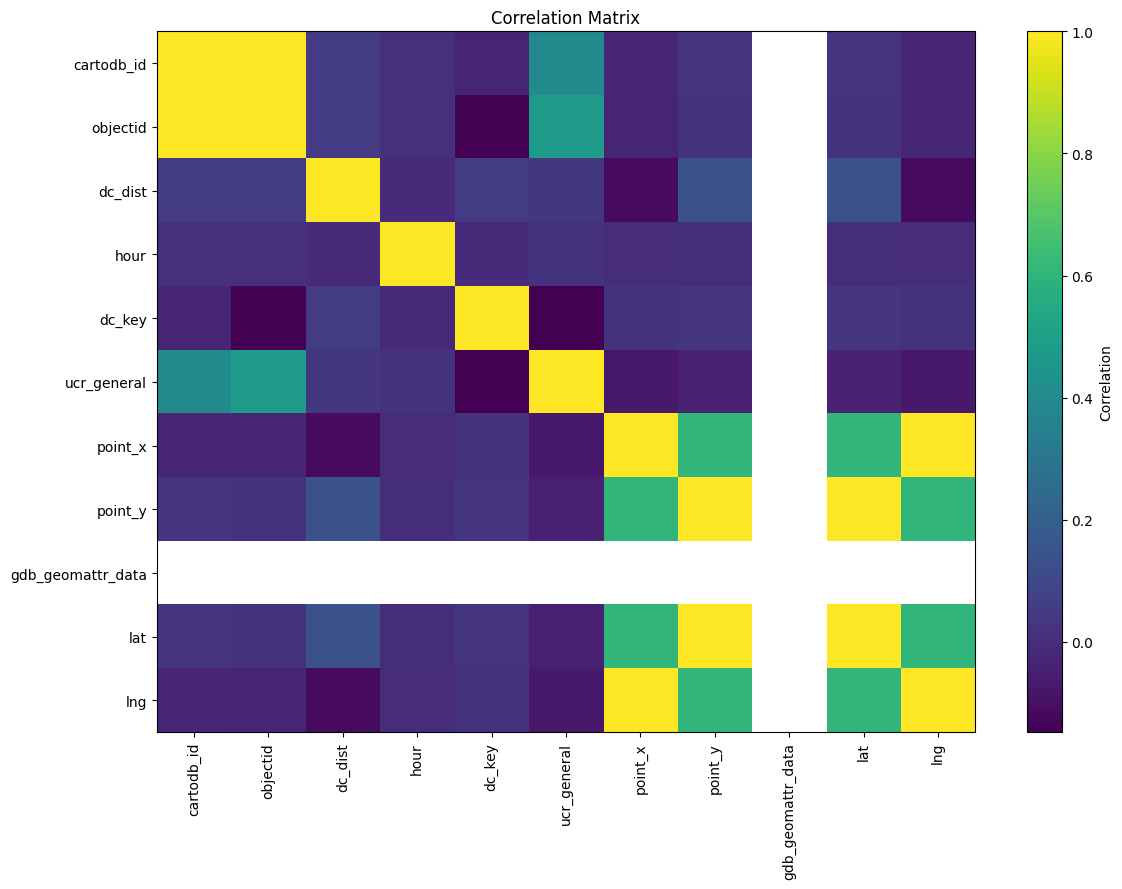

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Select numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr, cmap="viridis", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

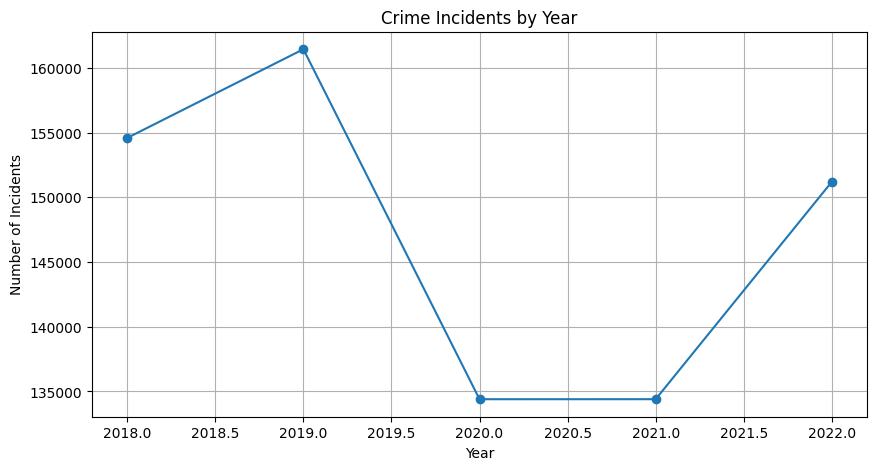

In [36]:
df["dispatch_date_time"] = pd.to_datetime(
    df["dispatch_date_time"],
    errors="coerce"
)

df["year"] = df["dispatch_date_time"].dt.year

year_counts = df["year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(year_counts.index, year_counts.values, marker="o")

plt.title("Crime Incidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.grid(True)
plt.show()

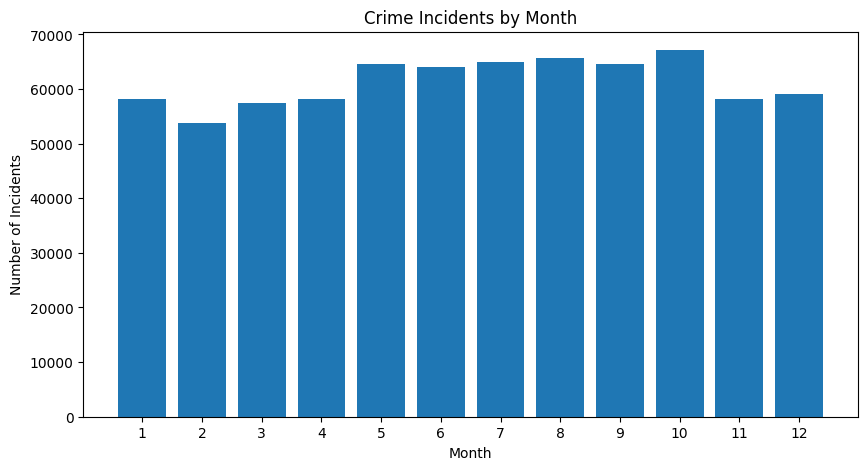

In [37]:
df["month"] = df["dispatch_date_time"].dt.month

month_counts = df["month"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(month_counts.index, month_counts.values)

plt.title("Crime Incidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.xticks(range(1, 13))
plt.show()

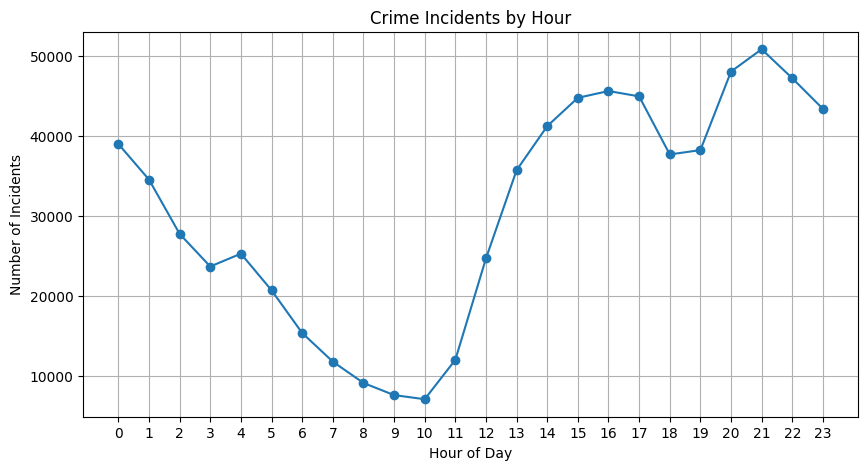

In [38]:
df["hour"] = df["dispatch_date_time"].dt.hour

hour_counts = df["hour"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(hour_counts.index, hour_counts.values, marker="o")

plt.title("Crime Incidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Incidents")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [39]:
category_columns = [
    col for col in df.columns
    if "category" in col.lower() or "crime" in col.lower()
]

print("Possible crime/category columns:")
print(category_columns)

Possible crime/category columns:
[]


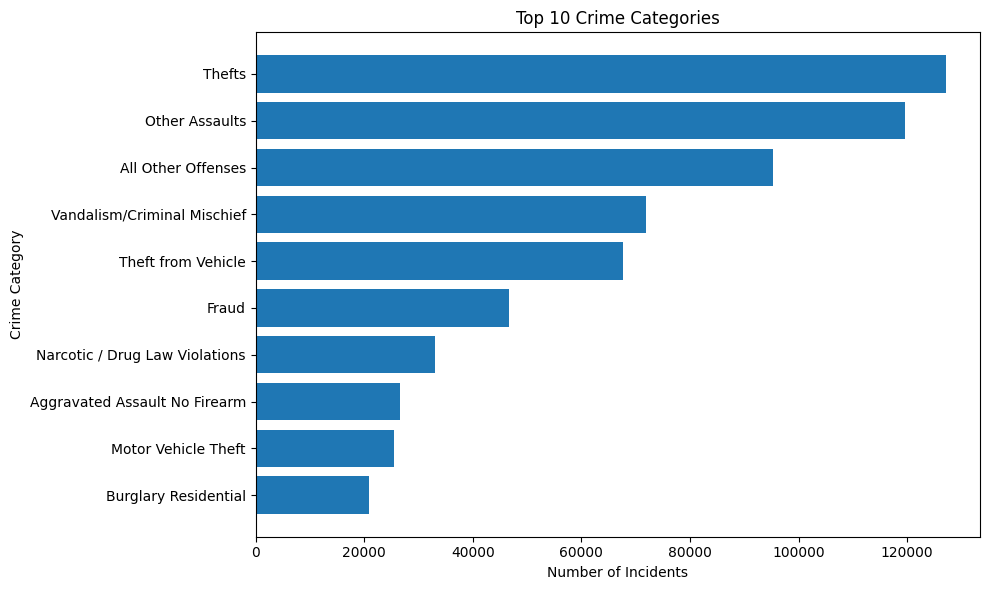

In [40]:
crime_col = "text_general_code"

top_crimes = df[crime_col].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_crimes.index.astype(str), top_crimes.values)

plt.title("Top 10 Crime Categories")
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

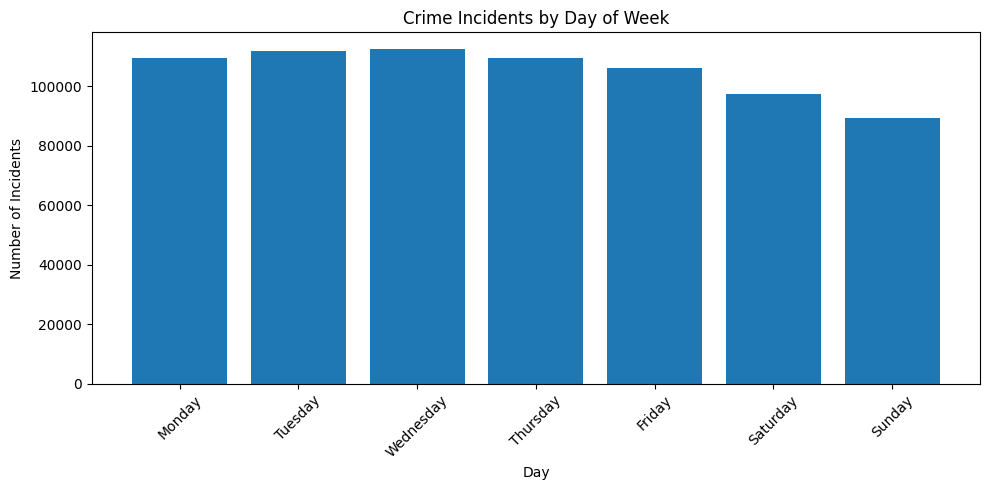

In [41]:
df["day_of_week"] = df["dispatch_date_time"].dt.day_name()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_counts = df["day_of_week"].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
plt.bar(day_counts.index, day_counts.values)

plt.title("Crime Incidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()